In [3]:
import pandas as pd
import spacy
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [25]:
# Load the Excel file containing skill roles
skill_roles_df = pd.read_excel('../annotated_skill_roles.xlsx')

# Function to load phrases from a file
def load_phrases(file_path):
    with open(file_path, 'r') as file:
        phrases = [line.strip() for line in file.readlines()]
    return phrases

# Load TASK and SKILLS phrases from files
task_phrases = load_phrases('task_phrases.txt')
skill_phrases = load_phrases('skill_phrases.txt')

# Initialize SpaCy for tokenization and lemmatization
nlp = spacy.load("en_core_web_sm")

# Function to extract vocabulary from text
def extract_vocabulary(text):
    doc = nlp(text.lower())  # Convert to lowercase for consistency
    tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and token.is_alpha]
    return set(tokens)  # Ensure the result is a set to get unique tokens

# Function to extract vocabulary and count word frequency from text
def extract_vocabulary_and_frequencies(text):
    doc = nlp(text.lower())  # Convert to lowercase for consistency
    tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]
    return Counter(tokens)


# Combine text from skill roles for key skills, tasks, and knowledge
skill_roles_text = ' '.join(skill_roles_df['key_skills'].dropna().tolist() +
                            skill_roles_df['main_tasks'].dropna().tolist() +
                            skill_roles_df['key_knowledge'].dropna().tolist())


# Extract vocabulary and word frequencies from skill roles text
skill_roles_vocab_freq = extract_vocabulary_and_frequencies(skill_roles_text)
skill_roles_vocab = set(skill_roles_vocab_freq.keys())

# Extract vocabulary from skill roles text
skill_roles_vocab = extract_vocabulary(skill_roles_text)

# Combine task and skill phrases into one text
phrases_text = ' '.join(task_phrases + skill_phrases)

# Extract vocabulary from the phrases
phrases_vocab = extract_vocabulary(phrases_text)

# Find the vocabulary that exists in the phrases annotation but is not used in the skill roles
exclusive_phrases_vocab = phrases_vocab - skill_roles_vocab

# Find the vocabulary that exists in skill roles but is not used in the phrases annotation
missing_vocab = skill_roles_vocab - phrases_vocab

# Find the common vocabulary between skill roles and the phrases annotation
common_vocab = skill_roles_vocab & phrases_vocab

# Display the vocabulary counts
print(f"Total vocabulary in skill roles: {len(skill_roles_vocab)}")
print("Sample vocabulary in skill roles:")
print(list(skill_roles_vocab)[:10])

print(f"\nTotal vocabulary in phrases annotation: {len(phrases_vocab)}")
print("Sample vocabulary in phrases annotation:")
print(list(phrases_vocab)[:10])

print(f"\nVocabulary present in skill roles but not used in annotation: {len(missing_vocab)}")
print("Sample vocabulary present in skill roles but not in annotation:")
print(list(missing_vocab)[:10])

print(f"\nVocabulary present in phrases annotation but not in skill roles: {len(exclusive_phrases_vocab)}")
print("Sample Vocabulary present in phrases annotation but not in skill roles:")
print(list(exclusive_phrases_vocab)[:10])



Total vocabulary in skill roles: 490
Sample vocabulary in skill roles:
['audience', 'ethically', 'idea', 'protect', 'material', 'securely', 'specification', 'ineffective', 'legal', 'finance']

Total vocabulary in phrases annotation: 277
Sample vocabulary in phrases annotation:
['campaign', 'practice', 'allocate', 'teach', 'architecture', 'evidence', 'performance', 'agreement', 'protect', 'contribute']

Vocabulary present in skill roles but not used in annotation: 247
Sample vocabulary present in skill roles but not in annotation:
['holder', 'audience', 'staff', 'impact', 'ethically', 'apt', 'idea', 'comprehension', 'relevant', 'simple']

Vocabulary present in phrases annotation but not in skill roles: 34
Sample Vocabulary present in phrases annotation but not in skill roles:
['promote', 'teach', 'hack', 'governance', 'oversee', 'harware', 'preservation', 'methodologie', 'agreement', 'inspection']


In [33]:
# 1. Extract vocabulary and word frequencies for TASK phrases
task_phrases_text = ' '.join(task_phrases)
task_vocab_freq = extract_vocabulary_and_frequencies(task_phrases_text)
task_vocab_unique = set(task_vocab_freq.keys())

# 2. Extract vocabulary and word frequencies for SKILL phrases
skill_phrases_text = ' '.join(skill_phrases)
skill_vocab_freq = extract_vocabulary_and_frequencies(skill_phrases_text)
skill_vocab_unique = set(skill_vocab_freq.keys())

# 3. Display the results for TASK phrases
total_task_words = sum(task_vocab_freq.values())  # Total number of words (with repetitions)
total_unique_task_vocab = len(task_vocab_unique)  # Total unique words

print(f"Total number of words in TASK phrases: {total_task_words}")
print(f"Total unique vocabulary in TASK phrases: {total_unique_task_vocab}")
print(f"Sample unique vocabulary in TASK phrases: {list(task_vocab_unique)[:10]}")

# 4. Display the results for SKILL phrases
total_skill_words = sum(skill_vocab_freq.values())  # Total number of words (with repetitions)
total_unique_skill_vocab = len(skill_vocab_unique)  # Total unique words

print(f"\nTotal number of words in SKILL phrases: {total_skill_words}")
print(f"Total unique vocabulary in SKILL phrases: {total_unique_skill_vocab}")
print(f"Sample unique vocabulary in SKILL phrases: {list(skill_vocab_unique)[:10]}")

Total number of words in TASK phrases: 168
Total unique vocabulary in TASK phrases: 131
Sample unique vocabulary in TASK phrases: ['practice', 'allocate', 'teach', 'evidence', 'protect', 'contribute', 'encourage', 'landscape', 'document', 'think']

Total number of words in SKILL phrases: 588
Total unique vocabulary in SKILL phrases: 192
Sample unique vocabulary in SKILL phrases: ['campaign', 'practice', 'teach', 'architecture', 'evidence', 'performance', 'agreement', 'gap', 'specification', 'ineffective']


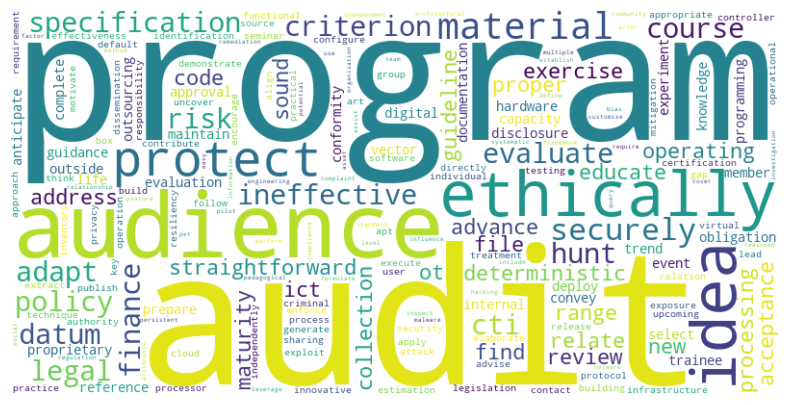

Sample vocabulary present in skill roles but not in annotation:
['holder', 'audience', 'staff', 'impact', 'ethically', 'apt', 'idea', 'comprehension', 'relevant', 'simple', 'user', 'legacy', 'intend', 'material', 'independently', 'securely', 'understand', 'subject', 'innovative', 'finance']


In [12]:
# Create a Word Cloud of the vocabulary from the skill roles
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(skill_roles_vocab))

# Plot the Word Cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off the axis
plt.show()

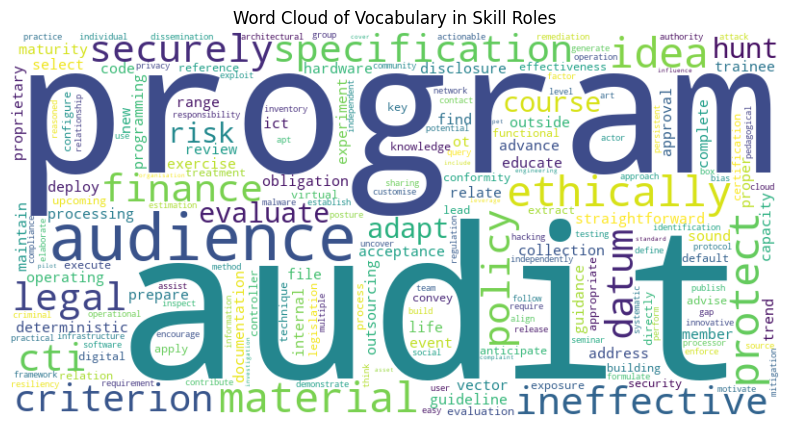

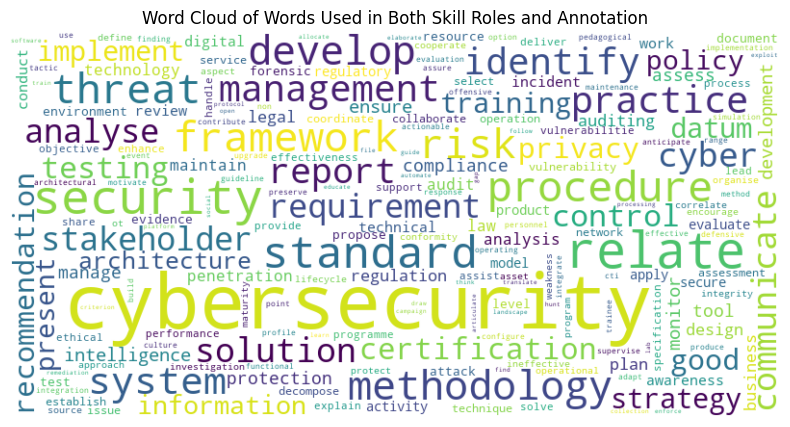

Sample vocabulary present in skill roles but not in annotation:
['holder', 'audience', 'staff', 'impact', 'ethically', 'apt', 'idea', 'comprehension', 'relevant', 'simple', 'user', 'legacy', 'intend', 'material', 'independently', 'securely', 'understand', 'subject', 'innovative', 'finance']


In [16]:
# Create a Word Cloud of the vocabulary from the skill roles
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(skill_roles_vocab))

# Plot the Word Cloud for skill roles vocabulary
plt.figure(figsize=(10, 5))
plt.title("Word Cloud of Vocabulary in Skill Roles")
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off the axis
plt.show()

# Create a Word Cloud for the common vocabulary (words used in skill roles and annotation)
common_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(
    {word: skill_roles_vocab_freq[word] for word in common_vocab}
)

# Plot the Word Cloud for words used in annotation
plt.figure(figsize=(10, 5))
plt.title("Word Cloud of Words Used in Both Skill Roles and Annotation")
plt.imshow(common_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Display some of the missing vocabulary
print("Sample vocabulary present in skill roles but not in annotation:")
print(list(missing_vocab)[:20])  # Display the first 20 words for a quick view

In [29]:
# Load the course details dataset (assuming it's an Excel file similar to skill roles)
course_details_df = pd.read_excel('../annotated_course_details.xlsx')

# Function to load phrases from a file
def load_phrases(file_path):
    with open(file_path, 'r') as file:
        phrases = [line.strip() for line in file.readlines()]
    return phrases

# Load TASK and SKILLS phrases from files
task_phrases = load_phrases('task_phrases.txt')
skill_phrases = load_phrases('skill_phrases.txt')

# Initialize SpaCy for tokenization and lemmatization
nlp = spacy.load("en_core_web_sm")

# Increase the max length to handle longer texts
nlp.max_length = 2000000  # Set to 2,000,000 characters, adjust as needed

# Function to extract vocabulary from text
def extract_vocabulary(text):
    doc = nlp(text.lower())  # Convert to lowercase for consistency
    tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and token.is_alpha]
    return set(tokens)  # Ensure the result is a set to get unique tokens

# Process course descriptions in chunks to avoid exceeding SpaCy's limit
def process_in_chunks(text, chunk_size=100000):
    vocab = set()
    for i in range(0, len(text), chunk_size):
        chunk = text[i:i + chunk_size]
        vocab.update(extract_vocabulary(chunk))
    return vocab

# Combine text from course details description
course_details_text = ' '.join(course_details_df['course detail description'].dropna().tolist())

# Extract unique vocabulary from course details text
course_details_vocab = extract_vocabulary(course_details_text)

# Combine task and skill phrases into one text
phrases_text = ' '.join(task_phrases + skill_phrases)

# Extract unique vocabulary from the phrases
phrases_vocab = extract_vocabulary(phrases_text)

# Find the vocabulary that exists in the course details but is not used in the phrases annotation
exclusive_course_vocab = course_details_vocab - phrases_vocab

# Find the vocabulary that exists in the phrases annotation but not used in the course details
missing_course_vocab = phrases_vocab - course_details_vocab

print(f"Total unique vocabulary in course details: {len(course_details_vocab)}")
print("Sample  unique vocabulary in course details:")
print(list(course_details_vocab)[:10])

print(f"\nTotal unique vocabulary in phrases annotation: {len(phrases_vocab)}")
print("Sample unique vocabulary in phrases annotation:")
print(list(phrases_vocab)[:10])

print(f"\nVocabulary present in course details but not in annotation: {len(exclusive_course_vocab)}")
print("Sample vocabulary present in course details but not in annotation:")
print(list(exclusive_course_vocab)[:10])

print(f"\nVocabulary present in phrases annotation but not used in course details: {len(missing_course_vocab)}")
print("Sample vocabulary present in phrases annotation but not used in course details:")
print(list(missing_course_vocab)[:10])

Total unique vocabulary in course details: 6295
Sample  unique vocabulary in course details:
['amplify', 'bear', 'drone', 'assembly', 'arbitrary', 'hadoop', 'partitioning', 'kiddy', 'replica', 'custom']

Total unique vocabulary in phrases annotation: 277
Sample unique vocabulary in phrases annotation:
['campaign', 'practice', 'allocate', 'teach', 'architecture', 'evidence', 'performance', 'agreement', 'protect', 'contribute']

Vocabulary present in course details but not in annotation: 6030
Sample vocabulary present in course details but not in annotation:
['amplify', 'bear', 'birthday', 'bank', 'transitivity', 'drone', 'enteprise', 'assembly', 'elaboration', 'declaration']

Vocabulary present in phrases annotation but not used in course details: 12
Sample vocabulary present in phrases annotation but not used in course details:
['pedagogical', 'trainee', 'clouds', 'harware', 'cti', 'oversee', 'methodologie', 'customise', 'actionable', 'unbiased']


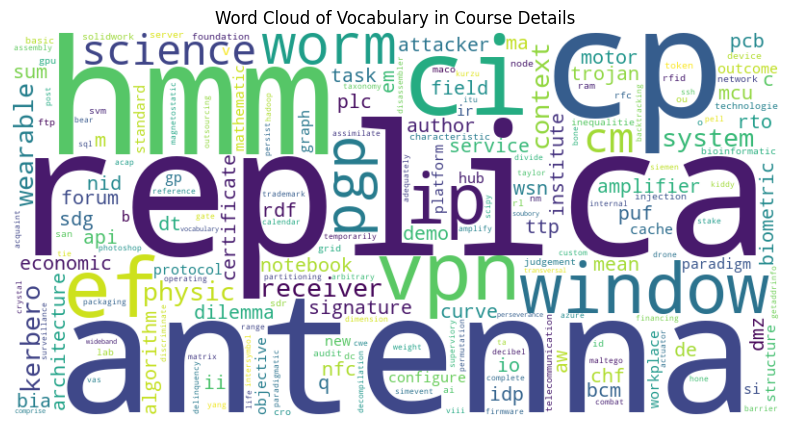

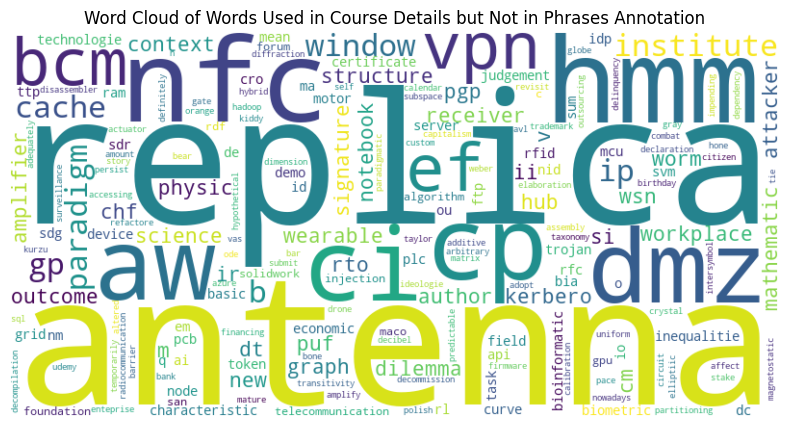

In [30]:
# Create a Word Cloud of the vocabulary from the course details
course_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(course_details_vocab))

# Plot the Word Cloud for course details vocabulary
plt.figure(figsize=(10, 5))
plt.title("Word Cloud of Vocabulary in Course Details")
plt.imshow(course_wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off the axis
plt.show()

# Create a Word Cloud for the exclusive vocabulary (words used in course details but not in phrases)
exclusive_course_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(exclusive_course_vocab))

# Plot the Word Cloud for words used in course details but not in phrases annotation
plt.figure(figsize=(10, 5))
plt.title("Word Cloud of Words Used in Course Details but Not in Phrases Annotation")
plt.imshow(exclusive_course_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# # Display some of the exclusive vocabulary
# print("Sample vocabulary present in course details but not in annotation:")
# print(list(exclusive_course_vocab)[:20])  # Display the first 20 words for a quick view